<a href="https://colab.research.google.com/github/vivek28n/fake-news-detection/blob/main/notebooks/Fake_News_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fake News Detection System

### Deep Learning Project

This project aims to classify news articles as Fake or Real using Deep Learning techniques, particularly LSTM.

In [1]:
!git clone https://github.com/vivek28n/fake-news-detection.git

Cloning into 'fake-news-detection'...
remote: Enumerating objects: 17, done.
remote: Counting objects: 100% (17/17), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 17 (delta 1), reused 10 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (17/17), 41.00 MiB | 38.48 MiB/s, done.
Resolving deltas: 100% (1/1), done.


In [2]:
import os

os.listdir('/content/fake-news-detection')

['README.md', 'notebooks', 'data', '.git', 'requirements.txt']

In [3]:
os.listdir('/content/fake-news-detection/data/raw')

['True.csv.zip', 'Fake.csv.zip']

In [4]:
import zipfile
import os

raw_path = '/content/fake-news-detection/data/raw'

for file in os.listdir(raw_path):
    if file.endswith('.zip'):
        with zipfile.ZipFile(os.path.join(raw_path, file), 'r') as zip_ref:
            zip_ref.extractall(raw_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [5]:
os.listdir(raw_path)

['True.csv.zip', 'Fake.csv', 'True.csv', 'Fake.csv.zip']

In [6]:
import os

raw_path = '/content/fake-news-detection/data/raw'

print(os.listdir(raw_path))

['True.csv.zip', 'Fake.csv', 'True.csv', 'Fake.csv.zip']


In [7]:
import pandas as pd

raw_path = '/content/fake-news-detection/data/raw'

fake = pd.read_csv(f'{raw_path}/Fake.csv')
real = pd.read_csv(f'{raw_path}/True.csv')

print("Fake News Shape:", fake.shape)
print("Real News Shape:", real.shape)

Fake News Shape: (23481, 4)
Real News Shape: (21417, 4)


In [8]:
fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [9]:
real.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [10]:
fake['label'] = 0
real['label'] = 1

In [11]:
fake.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [12]:
df = pd.concat([fake, real], ignore_index=True)

In [13]:
df.info

<bound method DataFrame.info of                                                    title  \
0       Donald Trump Sends Out Embarrassing New Year’...   
1       Drunk Bragging Trump Staffer Started Russian ...   
2       Sheriff David Clarke Becomes An Internet Joke...   
3       Trump Is So Obsessed He Even Has Obama’s Name...   
4       Pope Francis Just Called Out Donald Trump Dur...   
...                                                  ...   
44893  'Fully committed' NATO backs new U.S. approach...   
44894  LexisNexis withdrew two products from Chinese ...   
44895  Minsk cultural hub becomes haven from authorities   
44896  Vatican upbeat on possibility of Pope Francis ...   
44897  Indonesia to buy $1.14 billion worth of Russia...   

                                                    text    subject  \
0      Donald Trump just couldn t wish all Americans ...       News   
1      House Intelligence Committee Chairman Devin Nu...       News   
2      On Friday, it was revealed that former Milwauk...       News   
3      On Christmas day, Donald Trump announced that ...       News   
4      Pope Francis used his annual Christmas Day mes...       News   
...                                                  ...        ...   
44893  BRUSSELS (Reuters) - NATO allies on Tuesday we...  worldnews   
44894  LONDON (Reuters) - LexisNexis, a provider of l...  worldnews   
44895  MINSK (Reuters) - In the shadow of disused Sov...  worldnews   
44896  MOSCOW (Reuters) - Vatican Secretary of State ...  worldnews   
44897  JAKARTA (Reuters) - Indonesia will buy 11 Sukh...  worldnews   

                    date  label  
0      December 31, 2017      0  
1      December 31, 2017      0  
2      December 30, 2017      0  
3      December 29, 2017      0  
4      December 25, 2017      0  
...                  ...    ...  
44893   August 22, 2017       1  
44894   August 22, 2017       1  
44895   August 22, 2017       1  
44896   August 22, 2017       1  
44897   August 22, 2017       1  

[44898 rows x 5 columns]>

In [14]:
df.isnull().sum()

,0
title,0
text,0
subject,0
date,0
label,0


In [16]:
print("Duplicate rows:",df.duplicated().sum())

Duplicate rows: 209


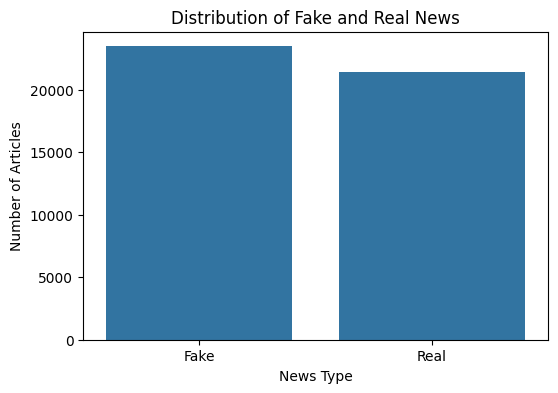

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.countplot(x='label', data=df)

plt.title('Distribution of Fake and Real News')
plt.xlabel('News Type')
plt.ylabel('Number of Articles')
plt.xticks([0, 1], ['Fake', 'Real'])

plt.show()

In [18]:
df['label'].value_counts()

,count
label,
0,23481
1,21417


In [19]:
df['label'].value_counts(normalize=True) * 100

,proportion
label,
0,52.298543
1,47.701457


In [20]:
df['text_length'] = df['text'].astype(str).apply(len)

df[['text_length', 'label']].head()

,text_length,label
0,2893,0
1,1898,0
2,3597,0
3,2774,0
4,2346,0


In [21]:
df.groupby('label')['text_length'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,23481.0,2547.396235,2532.884399,1.0,1433.0,2166.0,3032.0,51794.0
1,21417.0,2383.278517,1684.835730,1.0,914.0,2222.0,3237.0,29781.0


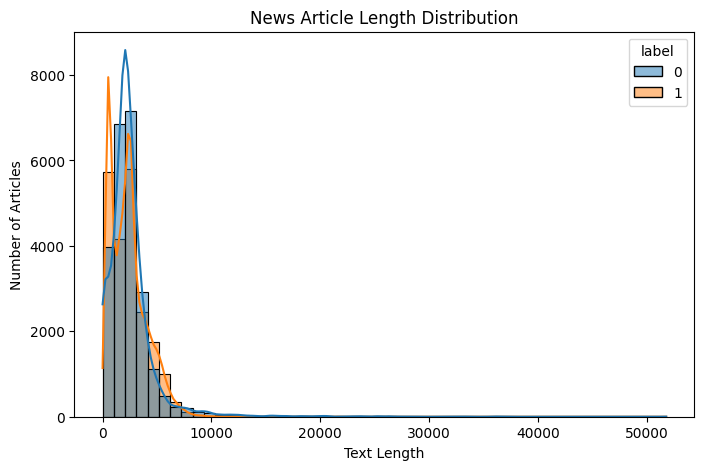

In [22]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='text_length',
    hue='label',
    bins=50,
    kde=True
)

plt.title('News Article Length Distribution')
plt.xlabel('Text Length')
plt.ylabel('Number of Articles')

plt.show()

In [23]:
df['subject'].value_counts()

,count
subject,
politicsNews,11272
worldnews,10145
News,9050
politics,6841
left-news,4459
Government News,1570
US_News,783
Middle-east,778


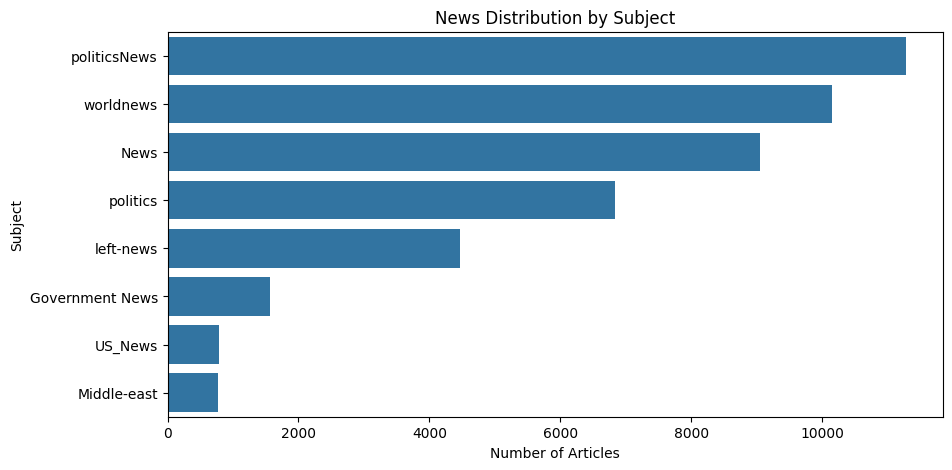

In [24]:
plt.figure(figsize=(10, 5))

sns.countplot(
    y='subject',
    data=df,
    order=df['subject'].value_counts().index
)

plt.title('News Distribution by Subject')
plt.xlabel('Number of Articles')
plt.ylabel('Subject')

plt.show()

In [25]:
print("Before removing duplicates:", df.shape)

df = df.drop_duplicates()

print("After removing duplicates:", df.shape)

Before removing duplicates: (44898, 6)
After removing duplicates: (44689, 6)


In [26]:
print(df.isnull().sum())

title          0
text           0
subject        0
date           0
label          0
text_length    0
dtype: int64


In [27]:
df = df.dropna(subset=['text'])

print("After removing missing text:", df.shape)

After removing missing text: (44689, 6)


In [28]:
df['content'] = df['title'].fillna('') + ' ' + df['text'].fillna('')

In [29]:
df[['title', 'text', 'content', 'label']].head()

,title,text,content,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,Donald Trump Sends Out Embarrassing New Year’...,0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,Drunk Bragging Trump Staffer Started Russian ...,0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",Sheriff David Clarke Becomes An Internet Joke...,0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",Trump Is So Obsessed He Even Has Obama’s Name...,0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,Pope Francis Just Called Out Donald Trump Dur...,0


In [31]:
print("Final dataset shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Final dataset shape: (44689, 7)

Missing values:
title          0
text           0
subject        0
date           0
label          0
text_length    0
content        0
dtype: int64

Duplicate rows: 0


In [32]:
print(df['label'].value_counts())

print("\nPercentage:")
print(df['label'].value_counts(normalize=True) * 100)

label
0    23478
1    21211
Name: count, dtype: int64

Percentage:
label
0    52.536418
1    47.463582
Name: proportion, dtype: float64


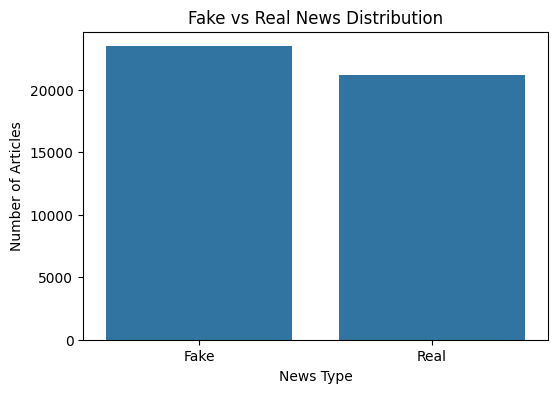

In [33]:
plt.figure(figsize=(6, 4))

sns.countplot(x='label', data=df)

plt.title('Fake vs Real News Distribution')
plt.xlabel('News Type')
plt.ylabel('Number of Articles')
plt.xticks([0, 1], ['Fake', 'Real'])

plt.show()